# Diabetic Retinopathy Stage Detection
## Notebook 2 of 2 — Augmentation, Transfer Learning, Evaluation & Demo

**Module:** Computer Vision | Coursework 1 | BSc (Hons) Computer Science

---

### Prerequisite

Notebook 1 must have completed. This notebook expects the following on Google Drive:

```
MyDrive/DR_CW/
├── processed_320.zip
└── artifacts/
    ├── class_weights.json
    └── splits/{train,val,test}.csv
```


### What this notebook does

Building on the preprocessed dataset and stratified splits from Notebook 1, this
notebook covers the full modelling pipeline:

1. **Augmentation** — a domain-appropriate augmentation strategy for retinal images,
   and handling of class imbalance via weighted loss.
2. **Model architecture** — three CNN backbones (EfficientNetB0, ResNet50,
   MobileNetV2) adapted through transfer learning from ImageNet.
3. **Training** — a two-stage fine-tuning schedule with appropriate callbacks and a
   frozen-BatchNorm strategy, followed by a hyperparameter tuning experiment.
4. **Evaluation** — accuracy, macro F1, and quadratic weighted kappa, alongside
   confusion matrices and per-class analysis.
5. **Interpretability** — Grad-CAM visualisations showing which image regions drove
   each prediction.
6. **Deployment prototype** — a Gradio interface for interactive demonstration.

### Expected runtime

About 3 hours on a T4 GPU: roughly 25–35 minutes per training run, with three
architectures plus two tuning runs. Set `QUICK_RUN = True` in the configuration cell
to smoke-test the whole pipeline on a small subset first (roughly 5 minutes).

**Keep the computer awake for the whole run.** If the browser loses its connection,
Colab keeps executing, but outputs produced while disconnected are not saved into the
notebook. All figures and tables are also written to Google Drive as a safeguard.

---
## 1. Setup

In [1]:
# --- Imports and reproducibility --------------------------------------------
import os, sys, json, time, random, shutil, zipfile, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("TensorFlow:", tf.__version__)
print("Keras     :", keras.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU       :", gpus if gpus else "NONE - enable Runtime > Change runtime type > T4 GPU")

TensorFlow: 2.20.0
Keras     : 3.13.2
GPU       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# --- Mixed precision ---------------------------------------------------------
# float16 compute with float32 weights. Roughly 1.5-2x faster on a T4 and halves
# activation memory. The output layer is forced back to float32 (see build_model)
# because softmax in float16 is numerically unstable.
USE_MIXED_PRECISION = True

if USE_MIXED_PRECISION and gpus:
    keras.mixed_precision.set_global_policy("mixed_float16")
print("Compute policy:", keras.mixed_precision.global_policy().name)

Compute policy: mixed_float16


In [3]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR  = Path("/content/drive/MyDrive/DR_CW")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
FIG_DIR      = ARTIFACT_DIR / "figures"
SPLIT_DIR    = ARTIFACT_DIR / "splits"
MODEL_DIR    = PROJECT_DIR / "models"
RESULT_DIR   = ARTIFACT_DIR / "results"

for d in (FIG_DIR, MODEL_DIR, RESULT_DIR):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
                     "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

def save_fig(name):
    path = FIG_DIR / f"{name}.png"
    plt.savefig(path)
    print(f"  saved -> {path.name}")
    return path

Mounted at /content/drive


In [ ]:
# --- Restore the preprocessed image cache from Drive ------------------------
PROC_DIR = Path("/content/processed")
IMG_CACHE = PROC_DIR / "images_320"

if not IMG_CACHE.exists():
    archive = PROJECT_DIR / "processed_320.zip"
    assert archive.exists(), f"Missing {archive}. Run Notebook 1 first."
    print("Restoring image cache from Drive...")
    PROC_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive) as zf:
        zf.extractall(PROC_DIR)

print(f"Cached images available: {len(list(IMG_CACHE.glob('*.jpg')))}")

Restoring image cache from Drive...
Cached images available: 3662


---
## 2. Experiment configuration

All tunable settings live in one place.


In [4]:
# --- Experiment configuration ------------------------------------------------
QUICK_RUN = False        # True = 2+2 epochs on a data subset, for debugging only

IMG_SIZE    = 224        # EfficientNetB0 / ResNet50 / MobileNetV2 native resolution
BATCH_SIZE  = 32
NUM_CLASSES = 5

EPOCHS_HEAD = 2 if QUICK_RUN else 10    # stage 1: frozen backbone
EPOCHS_FINE = 2 if QUICK_RUN else 20    # stage 2: fine-tuning
LR_HEAD     = 1e-3
LR_FINE     = 1e-5       # deliberately 100x smaller - see markdown in section 5
UNFREEZE_FRACTION = 0.30 # fraction of backbone layers unfrozen in stage 2
LABEL_SMOOTHING   = 0.0  # kept off; class_weight already softens the objective

CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

ARCHITECTURES = ["EfficientNetB0", "ResNet50", "MobileNetV2"]

config = dict(quick_run=QUICK_RUN, img_size=IMG_SIZE, batch_size=BATCH_SIZE,
              epochs_head=EPOCHS_HEAD, epochs_fine=EPOCHS_FINE,
              lr_head=LR_HEAD, lr_fine=LR_FINE,
              unfreeze_fraction=UNFREEZE_FRACTION, seed=SEED,
              mixed_precision=USE_MIXED_PRECISION)
print(json.dumps(config, indent=2))

{
  "quick_run": false,
  "img_size": 224,
  "batch_size": 32,
  "epochs_head": 10,
  "epochs_fine": 20,
  "lr_head": 0.001,
  "lr_fine": 1e-05,
  "unfreeze_fraction": 0.3,
  "seed": 42,
  "mixed_precision": true
}


In [5]:
# --- Load splits and class weights from Notebook 1 --------------------------
train_df = pd.read_csv(SPLIT_DIR / "train.csv")
val_df   = pd.read_csv(SPLIT_DIR / "val.csv")
test_df  = pd.read_csv(SPLIT_DIR / "test.csv")

with open(ARTIFACT_DIR / "class_weights.json") as f:
    class_weights = {int(k): float(v) for k, v in json.load(f).items()}

if QUICK_RUN:
    train_df = train_df.groupby("diagnosis", group_keys=False).head(60)
    val_df   = val_df.groupby("diagnosis", group_keys=False).head(20)
    print("QUICK_RUN active - using a small stratified subset\n")

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:<6} {len(d):>5} images")

print("\nClass weights:")
for c, w in class_weights.items():
    print(f"  {c} {CLASS_NAMES[c]:<18} {w:.3f}")

train   2562 images
val      550 images
test     550 images

Class weights:
  0 No DR              0.406
  1 Mild               1.986
  2 Moderate           0.733
  3 Severe             3.796
  4 Proliferative DR   2.475


---
## 3. Data augmentation and class imbalance

### 3.1 Choosing augmentations for fundus photographs

Augmentation must respect the domain. Two rules govern the choices below:

**Geometric transforms are safe.** A retina has no canonical orientation — the same eye
photographed with the camera rotated is still the same pathology. Flips (both axes),
rotations and modest zoom therefore generate genuinely plausible new images. Note that
horizontal flipping turns a left eye into something resembling a right eye, which is
realistic since the dataset contains both.

**Colour transforms must be gentle.** DR grading depends on colour: haemorrhages are dark
red, hard exudates are bright yellow-white, cotton-wool spots are pale grey. Aggressive
hue or saturation shifts would destroy the very signal the model needs. We therefore use
only small brightness and contrast jitter, simulating camera and illumination variation
rather than altering lesion appearance.

**Explicitly rejected:** vertical shear and heavy elastic deformation (distorts vessel
geometry, which is diagnostic), channel shuffling and hue rotation (destroys lesion
colour semantics), and Cutout/random erasing (risks deleting the single microaneurysm that
distinguishes grade 0 from grade 1).

### 3.2 Augmentation is applied to the training set only

Validation and test data pass through unaugmented. Augmenting them would mean measuring
performance on images that do not represent the deployment distribution, and would make
the results non-comparable with published work.

In [ ]:
# --- Augmentation pipeline (training set only) ------------------------------
augmenter = keras.Sequential([
    keras.layers.RandomFlip("horizontal_and_vertical"),
    keras.layers.RandomRotation(0.15),        # +/- 54 degrees
    keras.layers.RandomZoom(0.10),
    keras.layers.RandomTranslation(0.05, 0.05),
    keras.layers.RandomContrast(0.10),
    keras.layers.RandomBrightness(0.10, value_range=(0, 255)),
], name="augmenter")

print(augmenter.summary())

Model: "augmenter"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ ?                      │   0 (unbuilt) │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ ?                      │   0 (unbuilt) │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ ?                      │   0 (unbuilt) │
│ (RandomBrightness)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


### 3.3 Handling class imbalance

Three standard options, and why we chose the one we did:

| Approach | Effect | Verdict |
|---|---|---|
| **Oversampling** minority classes | Duplicates the 193 Severe images many times | Rejected — strong overfitting risk on so few unique images |
| **Undersampling** the majority | Discards most of the 1,805 No DR images | Rejected — throws away the majority of the dataset |
| **Class weighting** in the loss | Rare-class errors are penalised proportionally more | **Chosen** — uses all data, no duplication |

Class weighting is applied via Keras `class_weight`, computed by
`compute_class_weight("balanced")` in Notebook 1. A Severe (grade 3) example contributes
roughly 3.8x the loss of a No DR example, which pushes the model away from the degenerate
"predict No DR always" solution that would still score about 49% accuracy.

In [ ]:
# --- tf.data input pipeline --------------------------------------------------
AUTOTUNE = tf.data.AUTOTUNE

def decode_image(path, label):
    '''Read a cached JPEG and resize to the model's input resolution.

    Returns float32 in [0, 255]; model-specific normalisation is applied later,
    because each architecture expects a different input range.
    '''
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="bilinear")
    return tf.cast(img, tf.float32), label


def make_dataset(df, preprocess_fn, training=False, shuffle_buffer=1024):
    '''Build a batched tf.data pipeline from a split dataframe.

    Args:
        df:            dataframe with 'cached_path' and 'diagnosis' columns
        preprocess_fn: architecture-specific normalisation (e.g. resnet50.preprocess_input)
        training:      if True, shuffle and augment
    '''
    ds = tf.data.Dataset.from_tensor_slices(
        (df["cached_path"].values, df["diagnosis"].values.astype("int32")))

    ds = ds.map(decode_image, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()                       # 2.5k x 224x224x3 floats fits in Colab RAM

    if training:
        ds = ds.shuffle(shuffle_buffer, seed=SEED, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE)

    # Named functions rather than lambdas: tf.data's AutoGraph cannot parse two
    # lambdas with identical signatures defined in the same scope and emits a
    # warning on every call.
    def apply_augmentation(x, y):
        return augmenter(x, training=True), y

    def apply_normalisation(x, y):
        return preprocess_fn(x), y

    if training:
        # Augment on batches - much faster than per-image on GPU
        ds = ds.map(apply_augmentation, num_parallel_calls=AUTOTUNE)

    ds = ds.map(apply_normalisation, num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

  saved -> 07_augmentation_samples.png


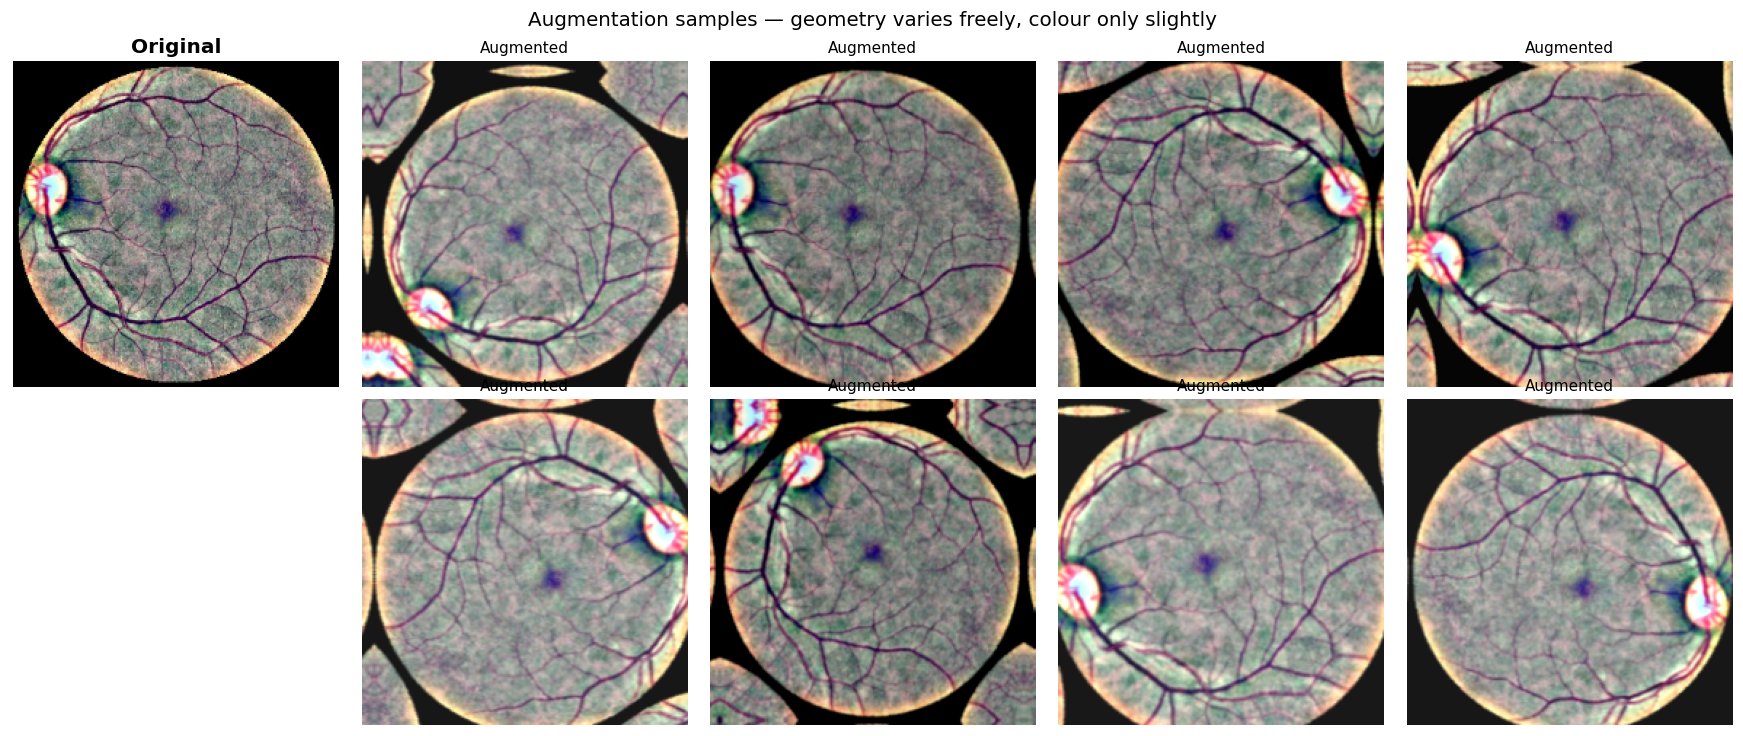

In [ ]:
# --- Visual check: what does the augmenter actually produce? ----------------
# An augmentation pipeline should always be inspected visually before training.

sample_path = train_df["cached_path"].iloc[7]
img, _ = decode_image(tf.constant(sample_path), tf.constant(0))
batch = tf.repeat(img[tf.newaxis, ...], 8, axis=0)
aug_batch = augmenter(batch, training=True)

fig, axes = plt.subplots(2, 5, figsize=(16, 6.8))
axes[0, 0].imshow(img.numpy().astype("uint8"))
axes[0, 0].set_title("Original", fontweight="bold")
axes[0, 0].axis("off")
axes[1, 0].axis("off")

flat = [axes[0, i] for i in range(1, 5)] + [axes[1, i] for i in range(1, 5)]
for ax, a in zip(flat, aug_batch):
    ax.imshow(np.clip(a.numpy(), 0, 255).astype("uint8"))
    ax.set_title("Augmented", fontsize=10)
    ax.axis("off")

plt.suptitle("Augmentation samples — geometry varies freely, colour only slightly",
             fontsize=13)
plt.tight_layout()
save_fig("07_augmentation_samples")
plt.show()

---
## 4. Model architecture

### 4.1 Why transfer learning is necessary here

Our training set is about 2,560 images across 5 classes — roughly 135 examples for the
Severe grade. A CNN trained from random initialisation on that much data will overfit
badly. ImageNet-pretrained weights supply general visual primitives (edges, textures,
blobs, colour opponency) learned from 1.2 million images. Those early-layer features
transfer well to fundus photographs even though ImageNet contains no medical imagery:
detecting a small round dark blob is the same computation whether the blob is a
microaneurysm or a berry.

### 4.2 Why compare three architectures

A single model gives nothing to evaluate against, so we train three that represent
different design philosophies:

| Architecture | Parameters | Design idea | Why included |
|---|---|---|---|
| **EfficientNetB0** | ~5.3 M | Compound scaling of depth/width/resolution | Strong accuracy per parameter; current standard for DR work |
| **ResNet50** | ~25.6 M | Residual skip connections | Widely used baseline; lets us test whether more capacity helps on small data |
| **MobileNetV2** | ~3.5 M | Depthwise-separable convolutions | Deployment realism — could run on a phone in a rural clinic |

### 4.3 Head design

`GlobalAveragePooling2D → Dropout(0.4) → Dense(5, softmax)`

Global average pooling rather than Flatten: it collapses the spatial map to one value per
channel, cutting parameters by orders of magnitude and imposing a useful structural prior.
Dropout at 0.4 is relatively aggressive, justified by the small dataset. The final Dense
layer is forced to float32 so that softmax is computed in full precision under the mixed
precision policy.

In [ ]:
# --- Architecture registry ---------------------------------------------------
# Each entry pairs a constructor with its required input normalisation.
# Getting this pairing wrong is a common and silent bug: EfficientNet in Keras
# has rescaling built in and expects raw [0, 255], whereas ResNet50 expects
# caffe-style mean-subtracted BGR and MobileNetV2 expects [-1, 1].

ARCH_REGISTRY = {
    "EfficientNetB0": (keras.applications.EfficientNetB0,
                       keras.applications.efficientnet.preprocess_input),
    "ResNet50":       (keras.applications.ResNet50,
                       keras.applications.resnet50.preprocess_input),
    "MobileNetV2":    (keras.applications.MobileNetV2,
                       keras.applications.mobilenet_v2.preprocess_input),
}


def build_model(arch_name, dropout=0.4):
    '''Construct backbone and classification head as separate referenceable models.

    Keeping the backbone and head as distinct objects (rather than one deeply
    nested model) makes Grad-CAM straightforward later: we can run the backbone,
    capture its feature map, and run the head on that map explicitly.

    Returns:
        model, backbone, head
    '''
    constructor, _ = ARCH_REGISTRY[arch_name]

    backbone = constructor(include_top=False, weights="imagenet",
                           input_shape=(IMG_SIZE, IMG_SIZE, 3))

    head = keras.Sequential([
        keras.layers.GlobalAveragePooling2D(name="gap"),
        keras.layers.Dropout(dropout, name="dropout"),
        # float32 output: softmax is unstable in float16
        keras.layers.Dense(NUM_CLASSES, activation="softmax",
                           dtype="float32", name="predictions"),
    ], name="head")

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
    model = keras.Model(inputs, head(backbone(inputs)), name=arch_name)
    return model, backbone, head


# Quick structural check
_m, _b, _h = build_model("EfficientNetB0")
print(f"Backbone layers : {len(_b.layers)}")
print(f"Total params    : {_m.count_params():,}")
del _m, _b, _h

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Backbone layers : 238
Total params    : 4,055,976


---
## 5. Training strategy

### Two-stage transfer learning

**Stage 1 — frozen backbone, learning rate 1e-3.**
The randomly initialised head produces large, essentially meaningless gradients at the
start of training. If the backbone were trainable, those gradients would propagate
backwards and destroy the pretrained weights before the head learned anything useful. We
therefore freeze the backbone entirely and train only the head until it stabilises.

**Stage 2 — partial unfreeze, learning rate 1e-5.**
We then unfreeze the top 30% of backbone layers. Early layers detect generic edges and
textures that need no adaptation; deep layers encode ImageNet-specific semantics (dog
breeds, vehicles) that must be re-specialised toward retinal lesions. The learning rate
drops by 100x because we are now making small corrections to good weights, not learning
from scratch.

**BatchNormalization layers stay frozen throughout.** This is the single most common
fine-tuning bug in Keras. An unfrozen BN layer keeps updating its running mean and variance
using small batches from a new domain, which corrupts the statistics the pretrained
convolutional weights depend on. Symptom: training accuracy climbs while validation
accuracy collapses.

### Callbacks

| Callback | Setting | Purpose |
|---|---|---|
| `EarlyStopping` | patience 6 on `val_loss`, restore best | Stops before memorisation; returns best weights, not last |
| `ReduceLROnPlateau` | factor 0.3, patience 3 | Lets the optimiser settle into a minimum it is bouncing around |
| `ModelCheckpoint` | best `val_loss`, `.keras` format | Survives a Colab disconnect mid-training |

We monitor **validation loss, not validation accuracy**. Under class weighting, accuracy is
dominated by the majority class and can stay flat while the model genuinely improves on
rare grades.

The tuning experiment in Section 6.1 showed that 1e-5 was too cautious; the final
model uses a fine-tuning learning rate of 1e-4.

In [ ]:
# --- Backbone freezing helpers ----------------------------------------------

def freeze_backbone(backbone):
    '''Stage 1: freeze everything.'''
    backbone.trainable = False


def unfreeze_top(backbone, fraction=UNFREEZE_FRACTION):
    '''Stage 2: unfreeze the deepest `fraction` of layers, keeping all BN frozen.

    Returns the number of layers made trainable.
    '''
    backbone.trainable = True
    cutoff = int(len(backbone.layers) * (1 - fraction))

    trainable_count = 0
    for i, layer in enumerate(backbone.layers):
        if i < cutoff:
            layer.trainable = False
        elif isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False      # critical - see markdown above
        else:
            layer.trainable = True
            trainable_count += 1

    return trainable_count, cutoff


def make_callbacks(run_name, stage):
    ckpt = MODEL_DIR / f"{run_name}_{stage}.keras"
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=6,
                                      restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                                          patience=3, min_lr=1e-8, verbose=1),
        keras.callbacks.ModelCheckpoint(str(ckpt), monitor="val_loss",
                                        save_best_only=True, verbose=0),
    ]

In [ ]:
def train_architecture(arch_name, lr_fine=LR_FINE, unfreeze_fraction=UNFREEZE_FRACTION, tag=""):
    '''Run the full two-stage training schedule for one architecture.

    lr_fine and unfreeze_fraction are exposed as arguments so the same function
    can be reused for the hyperparameter tuning experiment in section 6.1.
    `tag` is appended to saved file names so tuning runs do not overwrite each other.

    Returns a dict with the trained model, its sub-models, merged history and timings.
    '''
    print("=" * 74)
    print(f"  {arch_name}{tag}")
    print("=" * 74)

    _, preprocess_fn = ARCH_REGISTRY[arch_name]
    train_ds = make_dataset(train_df, preprocess_fn, training=True)
    val_ds   = make_dataset(val_df,   preprocess_fn, training=False)

    model, backbone, head = build_model(arch_name)
    t0 = time.time()

    # ---------- Stage 1: train the head on frozen features ----------
    freeze_backbone(backbone)
    model.compile(optimizer=keras.optimizers.Adam(LR_HEAD),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    print(f"\n[Stage 1] Frozen backbone | trainable params: "
          f"{sum(np.prod(w.shape) for w in model.trainable_weights):,.0f}")

    hist_head = model.fit(train_ds, validation_data=val_ds,
                          epochs=EPOCHS_HEAD, class_weight=class_weights, shuffle=False,
                          callbacks=make_callbacks(arch_name + tag, "head"), verbose=1)

    # ---------- Stage 2: fine-tune the deepest layers ----------
    n_trainable, cutoff = unfreeze_top(backbone, unfreeze_fraction)
    model.compile(optimizer=keras.optimizers.Adam(lr_fine),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    print(f"\n[Stage 2] Unfroze {n_trainable} layers above index {cutoff} "
          f"of {len(backbone.layers)} | BN layers kept frozen")

    hist_fine = model.fit(train_ds, validation_data=val_ds,
                          epochs=EPOCHS_FINE, class_weight=class_weights, shuffle=False,
                          callbacks=make_callbacks(arch_name + tag, "fine"), verbose=1)

    elapsed = time.time() - t0

    # Merge the two histories so curves can be plotted continuously
    history = {k: list(hist_head.history[k]) + list(hist_fine.history.get(k, []))
               for k in hist_head.history}
    history["stage_boundary"] = len(hist_head.history["loss"])

    model.save(MODEL_DIR / f"{arch_name}{tag}_final.keras")
    with open(RESULT_DIR / f"{arch_name}{tag}_history.json", "w") as f:
        json.dump(history, f)

    print(f"\n{arch_name}{tag} finished in {elapsed/60:.1f} min")
    return dict(name=arch_name, model=model, backbone=backbone, head=head,
                history=history, seconds=elapsed, preprocess=preprocess_fn)

In [ ]:
# --- Train all architectures -------------------------------------------------
# On a T4 this is roughly 25-35 minutes per architecture at full settings.
# Keep the browser tab active; Colab disconnects idle sessions.

results = {}
for arch in ARCHITECTURES:
    results[arch] = train_architecture(arch)
    tf.keras.backend.clear_session()      # release GPU memory between runs

print("\nAll architectures trained.")

  EfficientNetB0

[Stage 1] Frozen backbone | trainable params: 6,405
Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.4684 - loss: 1.4698 - val_accuracy: 0.6673 - val_loss: 0.8793 - learning_rate: 0.0010
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 61s 747ms/step - accuracy: 0.5788 - loss: 1.2397 - val_accuracy: 0.7382 - val_loss: 0.7897 - learning_rate: 0.0010
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 61s 746ms/step - accuracy: 0.6116 - loss: 1.1855 - val_accuracy: 0.7400 - val_loss: 0.7298 - learning_rate: 0.0010
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 61s 746ms/step - accuracy: 0.6284 - loss: 1.1403 - val_accuracy: 0.7545 - val_loss: 0.7113 - learning_rate: 0.0010
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 61s 748ms/step - accuracy: 0.6265 - loss: 1.1063 - val_accuracy: 0.7655 - val_loss: 0.6924 - learning_rate: 0.0010
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 61s 743ms/step - accuracy: 0.6393 - loss: 1.0570 - val_accuracy: 0.7709 - val_loss: 0.6728 - learning_rate: 0.0010
Epoch 7/10
81/

---
## 6. Evaluation

### Why accuracy alone is not enough

Predicting "No DR" for every image scores about 49% accuracy on this dataset while being
clinically worthless. Three additional measures are reported:

**Per-class recall** — the fraction of true Severe cases the model actually catches. In a
screening context a false negative (missed proliferative DR) risks blindness, while a false
positive costs an unnecessary referral. These errors are not symmetric and a single
accuracy number hides that entirely.

**Macro F1** — averages F1 across classes with equal weight, so the 193-image Severe class
counts as much as the 1,805-image No DR class.

**Quadratic weighted kappa (QWK)** — the official metric of the APTOS competition. DR grades
are *ordinal*: predicting grade 3 when the truth is grade 4 is a minor error, predicting
grade 0 is a serious one. QWK penalises errors by the square of their distance on the
severity scale. Standard accuracy treats both mistakes identically, which is wrong for this
problem. Reporting QWK also allows direct comparison with published results on this
dataset.

In [ ]:
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             cohen_kappa_score, f1_score, roc_auc_score)

def evaluate_model(res):
    '''Run the model over the held-out test set and compute all evaluation metrics.'''
    test_ds = make_dataset(test_df, res["preprocess"], training=False)

    probs = res["model"].predict(test_ds, verbose=0)
    y_pred = probs.argmax(axis=1)
    y_true = test_df["diagnosis"].values

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "params": int(res["model"].count_params()),
        "train_minutes": round(res["seconds"] / 60, 1),
    }
    try:
        metrics["macro_auc"] = roc_auc_score(y_true, probs, multi_class="ovr",
                                             average="macro")
    except ValueError:
        metrics["macro_auc"] = float("nan")   # a class missing from the test split

    return metrics, y_true, y_pred, probs


evaluations = {}
for arch, res in results.items():
    m, y_true, y_pred, probs = evaluate_model(res)
    evaluations[arch] = dict(metrics=m, y_true=y_true, y_pred=y_pred, probs=probs)
    print(f"{arch:<16} acc={m['accuracy']:.4f}  macroF1={m['macro_f1']:.4f}  "
          f"QWK={m['qwk']:.4f}")

EfficientNetB0   acc=0.7618  macroF1=0.5964  QWK=0.8313
ResNet50         acc=0.7418  macroF1=0.5681  QWK=0.8411
MobileNetV2      acc=0.7018  macroF1=0.5292  QWK=0.8074


In [ ]:
# --- Architecture comparison table -------------------------------------------
comparison = pd.DataFrame({a: e["metrics"] for a, e in evaluations.items()}).T
comparison = comparison[["accuracy", "macro_f1", "weighted_f1", "qwk",
                         "macro_auc", "params", "train_minutes"]]
comparison.columns = ["Test Accuracy", "Test Macro F1", "Test Weighted F1", "Test QWK",
                      "Test Macro AUC", "Parameters", "Train (min)"]


def val_qwk(res):
    '''QWK on the VALIDATION set.

    Model selection must never look at the test set - otherwise the test score is
    no longer an unbiased estimate of real-world performance. The test set is only
    used once, to report the final numbers of the model chosen here.
    '''
    ds = make_dataset(val_df, res["preprocess"], training=False)
    pred = res["model"].predict(ds, verbose=0).argmax(axis=1)
    return cohen_kappa_score(val_df["diagnosis"].values, pred, weights="quadratic")


comparison.insert(0, "Val QWK", [val_qwk(results[a]) for a in comparison.index])
display(comparison.round(4))
comparison.round(4).to_csv(RESULT_DIR / "architecture_comparison.csv")

BEST = comparison["Val QWK"].idxmax()     # chosen on validation, never on test
print(f"\nBest architecture by VALIDATION QWK: {BEST}")
print("(Provisional - the tuned models in Section 6.1 also compete for final selection.)")

,Val QWK,Test Accuracy,Test Macro F1,Test Weighted F1,Test QWK,Test Macro AUC,Parameters,Train (min)
EfficientNetB0,0.8034,0.7618,0.5964,0.7653,0.8313,0.9121,4055976.0,28.4
ResNet50,0.8393,0.7418,0.5681,0.7390,0.8411,0.9098,23597957.0,25.5
MobileNetV2,0.7914,0.7018,0.5292,0.7001,0.8074,0.9098,2264389.0,35.3



Best architecture by VALIDATION QWK: ResNet50
(Provisional - the tuned models in Section 6.1 also compete for final selection.)


### 6.1 Hyperparameter tuning (fine-tuning stage)

The two fine-tuning hyperparameters with the largest effect are the **fine-tuning learning
rate** and **how much of the backbone is unfrozen**. Both are tested here on EfficientNetB0
(the fastest architecture to train), with every alternative compared on **validation QWK
only** so the test set stays untouched.

| Run | Fine-tune LR | Unfrozen fraction | Rationale |
|---|---|---|---|
| Baseline | 1e-5 | 0.30 | Already trained above |
| A | 1e-4 | 0.30 | Is the baseline learning rate too cautious? |
| B | 1e-5 | 0.50 | Does adapting more of the backbone help? |

The tuned models then join the three baseline architectures as candidates, and the
**final model is the candidate with the highest validation QWK**. Its test-set scores are
reported once and are never used to choose it. All later sections (per-class analysis,
error analysis, Grad-CAM, demo) use this final model.

Each run takes roughly 30 minutes on a T4. Set `RUN_TUNING = False` to skip it.

  EfficientNetB0_tuneA

[Stage 1] Frozen backbone | trainable params: 6,405
Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.4676 - loss: 1.4721 - val_accuracy: 0.6109 - val_loss: 0.9585 - learning_rate: 0.0010
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 62s 750ms/step - accuracy: 0.5742 - loss: 1.2523 - val_accuracy: 0.7036 - val_loss: 0.8211 - learning_rate: 0.0010
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 61s 748ms/step - accuracy: 0.6187 - loss: 1.1795 - val_accuracy: 0.7455 - val_loss: 0.7647 - learning_rate: 0.0010
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 62s 753ms/step - accuracy: 0.6315 - loss: 1.0963 - val_accuracy: 0.7273 - val_loss: 0.7490 - learning_rate: 0.0010
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 81s 746ms/step - accuracy: 0.6417 - loss: 1.0874 - val_accuracy: 0.7273 - val_loss: 0.7351 - learning_rate: 0.0010
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 62s 757ms/step - accuracy: 0.6483 - loss: 1.0544 - val_accuracy: 0.7364 - val_loss: 0.7040 - learning_rate: 0.0010
Epoch 7/

,run,lr_fine,unfreeze_fraction,val_QWK,best_val_loss
0,Baseline,0.0000,0.3,0.8034,0.6266
1,A,0.0001,0.3,0.8571,0.5147
2,B,0.0000,0.5,0.8405,0.5851


  saved -> 08b_tuning_curves.png


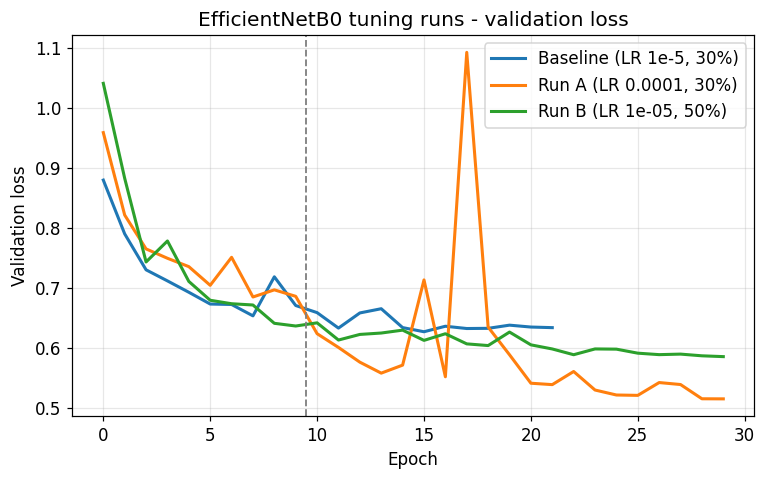

,Val QWK,Test Accuracy,Test Macro F1,Test QWK,Test Macro AUC,Parameters
EfficientNetB0,0.8034,0.7618,0.5964,0.8313,0.9121,4055976.0
ResNet50,0.8393,0.7418,0.5681,0.8411,0.9098,23597957.0
MobileNetV2,0.7914,0.7018,0.5292,0.8074,0.9098,2264389.0
EfficientNetB0 (tuned A),0.8571,0.7800,0.6394,0.8700,0.9312,4055976.0
EfficientNetB0 (tuned B),0.8405,0.7673,0.6101,0.8462,0.9190,4055976.0



FINAL model selected on validation QWK: EfficientNetB0 (tuned A)
Its test QWK (reported once, not used for selection): 0.8700


In [ ]:
# --- Hyperparameter tuning experiment ------------------------------------------
RUN_TUNING = True      # ~60 min extra GPU time; set False to skip

if RUN_TUNING:
    base = results["EfficientNetB0"]
    rows = [{"run": "Baseline", "lr_fine": LR_FINE, "unfreeze_fraction": UNFREEZE_FRACTION,
             "val_QWK": val_qwk(base), "best_val_loss": min(base["history"]["val_loss"])}]

    grid = [("A", 1e-4, 0.30), ("B", 1e-5, 0.50)]
    for name, lr, uf in grid:
        r = train_architecture("EfficientNetB0", lr_fine=lr, unfreeze_fraction=uf,
                               tag=f"_tune{name}")
        key = f"EfficientNetB0 (tuned {name})"
        results[key] = r                                  # becomes a selection candidate
        rows.append({"run": name, "lr_fine": lr, "unfreeze_fraction": uf,
                     "val_QWK": val_qwk(r), "best_val_loss": min(r["history"]["val_loss"])})
        tf.keras.backend.clear_session()

    tuning = pd.DataFrame(rows)
    display(tuning.round(4))
    tuning.round(4).to_csv(RESULT_DIR / "hyperparameter_tuning.csv", index=False)

    # Validation-loss curves: how each setting behaved during training
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(base["history"]["val_loss"], lw=2, label="Baseline (LR 1e-5, 30%)")
    for name, lr, uf in grid:
        h = results[f"EfficientNetB0 (tuned {name})"]["history"]
        ax.plot(h["val_loss"], lw=2, label=f"Run {name} (LR {lr:g}, {int(uf*100)}%)")
    ax.axvline(base["history"]["stage_boundary"] - 0.5, ls="--", c="grey", lw=1.2)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Validation loss")
    ax.set_title("EfficientNetB0 tuning runs - validation loss")
    ax.legend()
    save_fig("08b_tuning_curves")
    plt.show()

    # ---- Final model selection: all candidates, validation QWK only ----
    for key in [k for k in results if k not in evaluations]:
        m, y_t, y_p, pr = evaluate_model(results[key])
        evaluations[key] = dict(metrics=m, y_true=y_t, y_pred=y_p, probs=pr)

    final = pd.DataFrame({k: e["metrics"] for k, e in evaluations.items()}).T
    final = final[["accuracy", "macro_f1", "qwk", "macro_auc", "params"]]
    final.columns = ["Test Accuracy", "Test Macro F1", "Test QWK", "Test Macro AUC", "Parameters"]
    final.insert(0, "Val QWK", [val_qwk(results[k]) for k in final.index])
    display(final.round(4))
    final.round(4).to_csv(RESULT_DIR / "final_model_comparison.csv")

    BEST = final["Val QWK"].idxmax()
    print(f"\nFINAL model selected on validation QWK: {BEST}")
    print(f"Its test QWK (reported once, not used for selection): {final.loc[BEST, 'Test QWK']:.4f}")
else:
    print("Tuning skipped (RUN_TUNING = False). Final model:", BEST)

  saved -> 08_training_curves.png


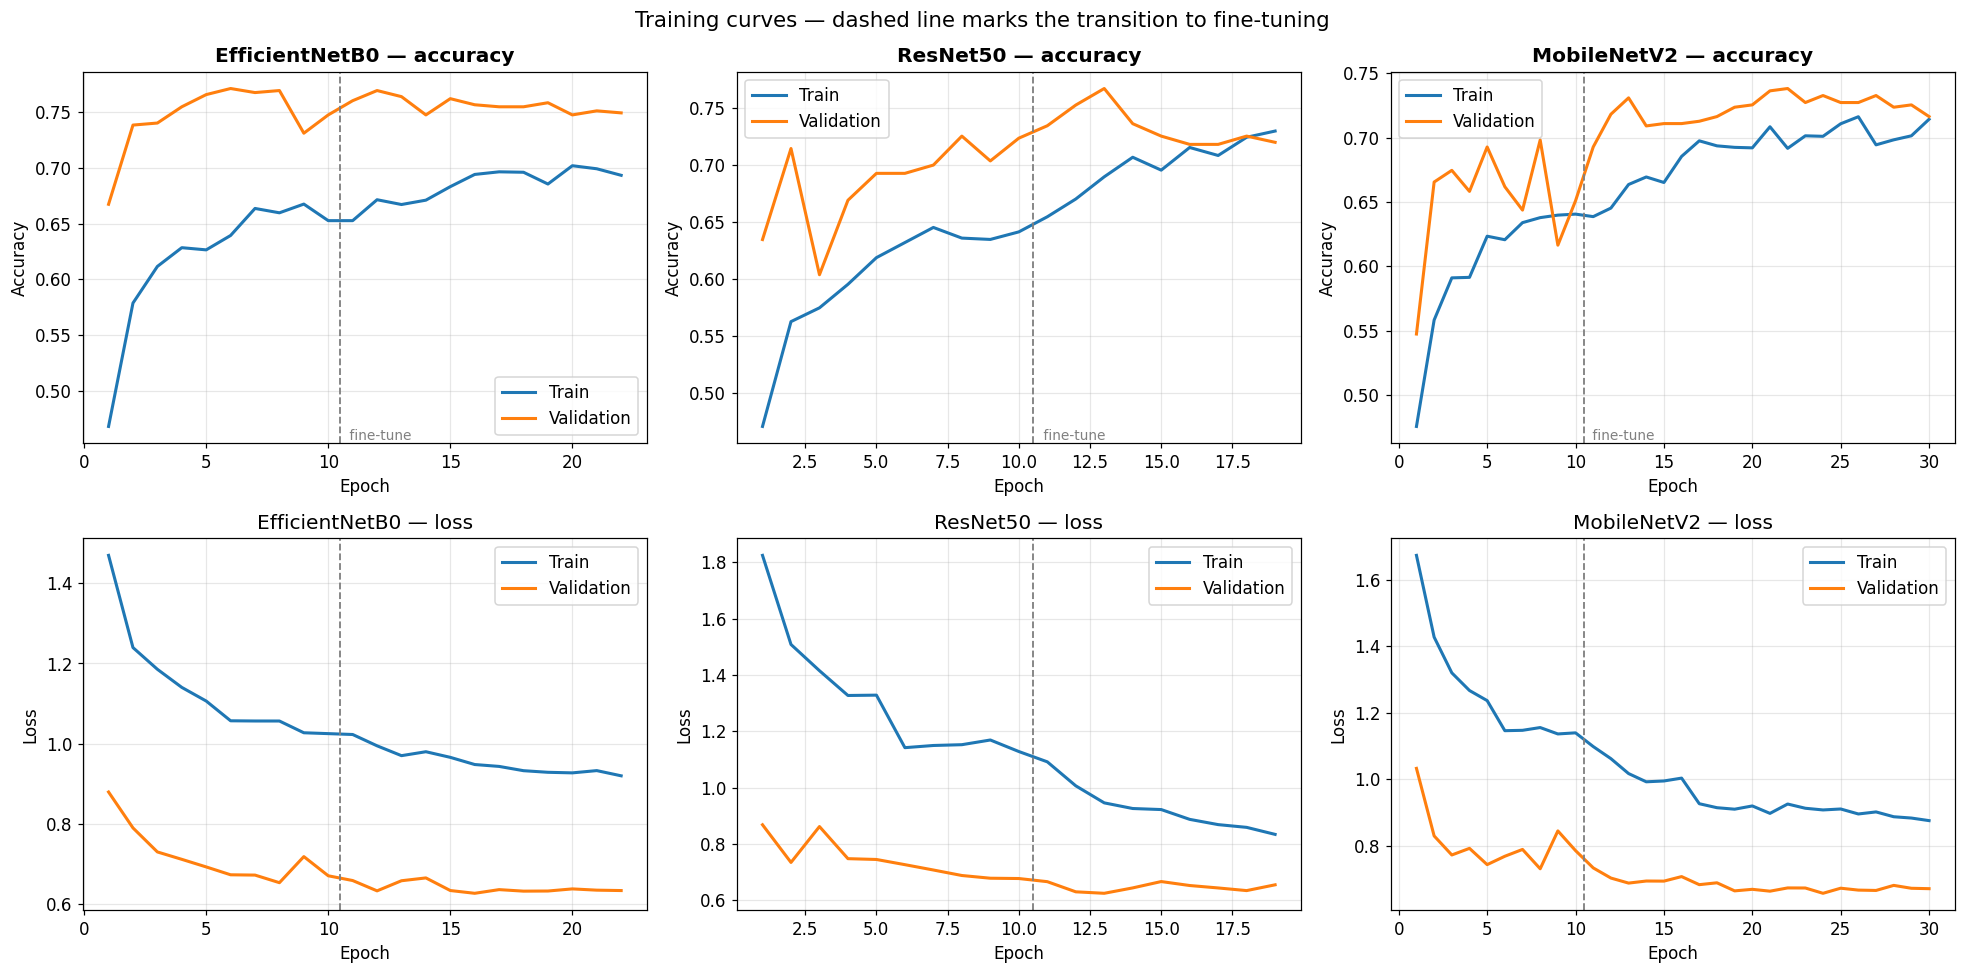

In [ ]:
# --- Accuracy and loss curves ------------------------------------------------
fig, axes = plt.subplots(2, len(ARCHITECTURES), figsize=(6 * len(ARCHITECTURES), 9))
if len(ARCHITECTURES) == 1:
    axes = axes.reshape(2, 1)

for j, arch in enumerate(ARCHITECTURES):
    h = results[arch]["history"]
    boundary = h["stage_boundary"]
    epochs = range(1, len(h["loss"]) + 1)

    axes[0, j].plot(epochs, h["accuracy"], label="Train", lw=2)
    axes[0, j].plot(epochs, h["val_accuracy"], label="Validation", lw=2)
    axes[0, j].axvline(boundary + 0.5, ls="--", c="grey", lw=1.2)
    axes[0, j].text(boundary + 0.7, axes[0, j].get_ylim()[0], " fine-tune",
                    fontsize=9, color="grey", va="bottom")
    axes[0, j].set_title(f"{arch} — accuracy", fontweight="bold")
    axes[0, j].set_xlabel("Epoch"); axes[0, j].set_ylabel("Accuracy")
    axes[0, j].legend()

    axes[1, j].plot(epochs, h["loss"], label="Train", lw=2)
    axes[1, j].plot(epochs, h["val_loss"], label="Validation", lw=2)
    axes[1, j].axvline(boundary + 0.5, ls="--", c="grey", lw=1.2)
    axes[1, j].set_title(f"{arch} — loss")
    axes[1, j].set_xlabel("Epoch"); axes[1, j].set_ylabel("Loss")
    axes[1, j].legend()

plt.suptitle("Training curves — dashed line marks the transition to fine-tuning",
             fontsize=14)
plt.tight_layout()
save_fig("08_training_curves")
plt.show()

**How to read these curves.** The gap between the two lines tells the real story:

- A validation curve tracking training closely → the model is generalising.
- Training accuracy rising while validation flattens → overfitting; note at which epoch it
  started and what stopped it (early stopping, dropout, augmentation).
- A visible jump at the dashed line → fine-tuning delivered real benefit, quantifiable in
  percentage points.
- Validation *below* training loss (or *above* training accuracy) early on is normal with
  dropout, which is active during training but disabled at validation — this gives the
  validation pass access to the network's full capacity while training does not.

  saved -> 09_confusion_matrices.png


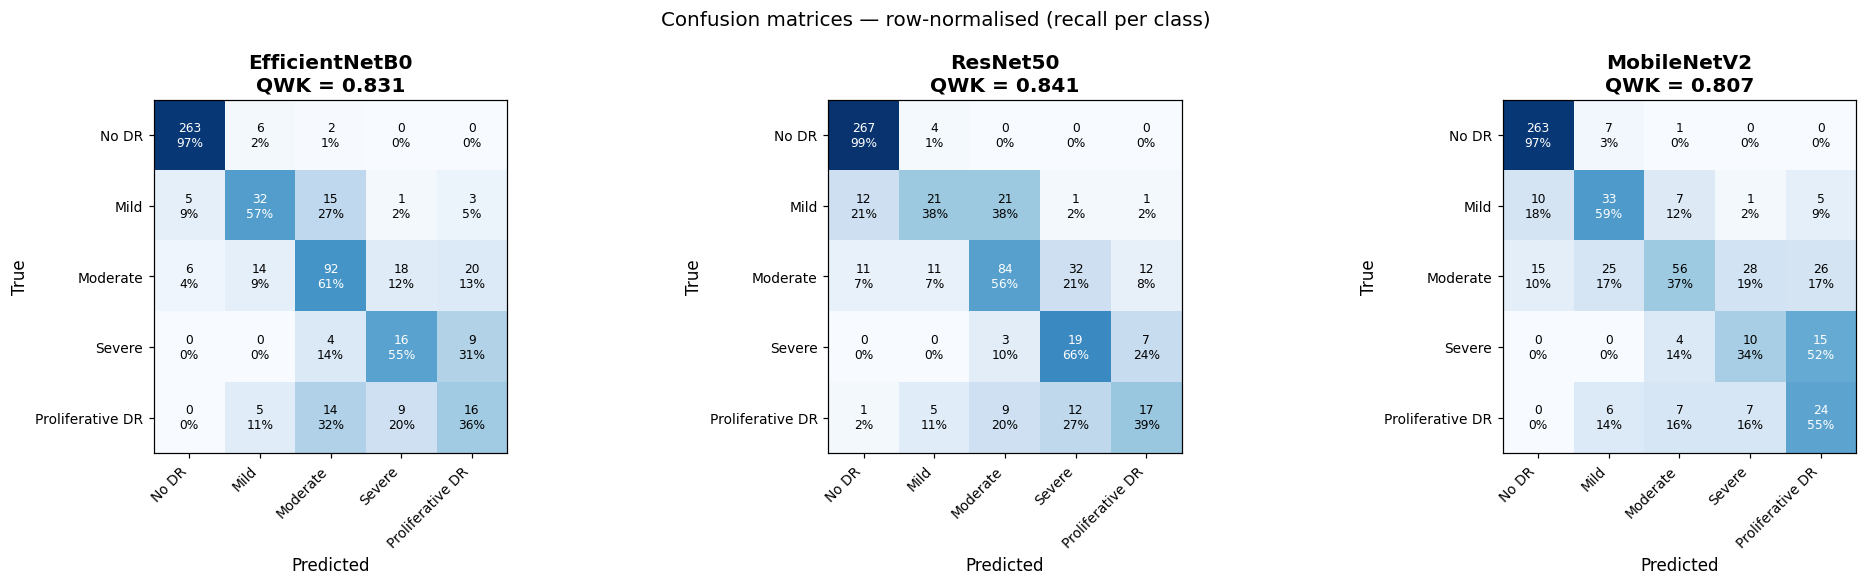

In [ ]:
# --- Confusion matrices ------------------------------------------------------
fig, axes = plt.subplots(1, len(ARCHITECTURES), figsize=(6.2 * len(ARCHITECTURES), 5.4))
if len(ARCHITECTURES) == 1:
    axes = [axes]

for ax, arch in zip(axes, ARCHITECTURES):
    e = evaluations[arch]
    cm = confusion_matrix(e["y_true"], e["y_pred"], labels=range(NUM_CLASSES))
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(CLASS_NAMES, fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{arch}\nQWK = {e['metrics']['qwk']:.3f}", fontweight="bold")
    ax.grid(False)

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm[i, j]}\n{cm_norm[i, j]*100:.0f}%",
                    ha="center", va="center", fontsize=8,
                    color="white" if cm_norm[i, j] > 0.5 else "black")

plt.suptitle("Confusion matrices — row-normalised (recall per class)", fontsize=13)
plt.tight_layout()
save_fig("09_confusion_matrices")
plt.show()

,precision,recall,f1-score,support
No DR,0.978,0.974,0.976,271.0
Mild,0.507,0.661,0.574,56.0
Moderate,0.768,0.573,0.656,150.0
Severe,0.362,0.586,0.447,29.0
Proliferative DR,0.521,0.568,0.543,44.0


  saved -> 10_per_class_metrics.png


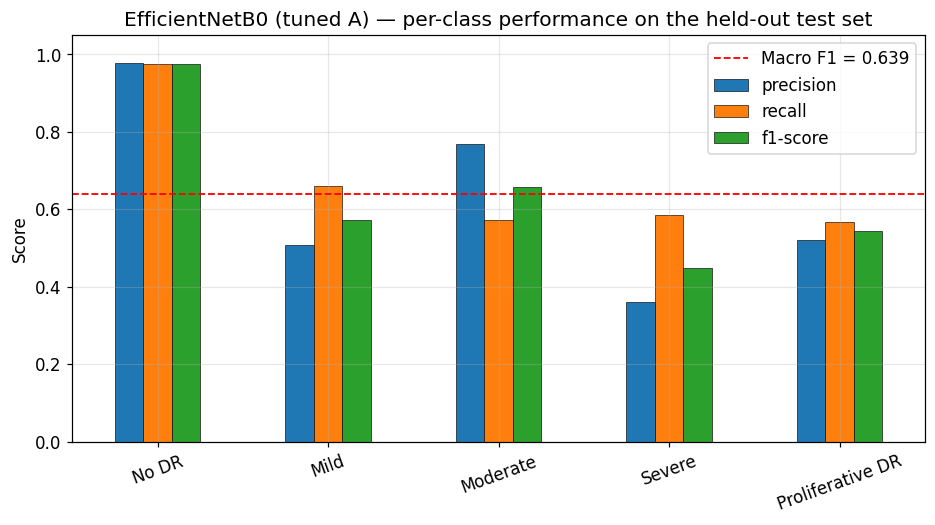

In [ ]:
# --- Per-class precision / recall / F1 for the best model -------------------
e = evaluations[BEST]
report = classification_report(e["y_true"], e["y_pred"],
                               labels=range(NUM_CLASSES),
                               target_names=CLASS_NAMES,
                               output_dict=True, zero_division=0)

per_class = pd.DataFrame(report).T.loc[CLASS_NAMES, ["precision", "recall", "f1-score", "support"]]
display(per_class.round(3))
per_class.round(3).to_csv(RESULT_DIR / "final_model_per_class_metrics.csv")

ax = per_class[["precision", "recall", "f1-score"]].plot(
    kind="bar", figsize=(10, 4.8), edgecolor="black", linewidth=0.4)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_title(f"{BEST} — per-class performance on the held-out test set")
ax.axhline(e["metrics"]["macro_f1"], ls="--", c="red", lw=1.2,
           label=f"Macro F1 = {e['metrics']['macro_f1']:.3f}")
ax.legend()
plt.xticks(rotation=20)
save_fig("10_per_class_metrics")
plt.show()

---
## 7. Error analysis

Beyond the confusion matrix, this section looks at *which* errors happen and whether they
are clinically reasonable.

In [ ]:
# --- Which class pairs are confused most, and how severe are the errors? ----
e = evaluations[BEST]
cm = confusion_matrix(e["y_true"], e["y_pred"], labels=range(NUM_CLASSES))

pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            pairs.append({
                "True": CLASS_NAMES[i], "Predicted": CLASS_NAMES[j],
                "Count": int(cm[i, j]),
                "Grade distance": abs(i - j),
                "Direction": "under-graded" if j < i else "over-graded",
            })

errors = pd.DataFrame(pairs).sort_values("Count", ascending=False)
display(errors.head(10))
errors.to_csv(RESULT_DIR / "final_model_error_pairs.csv", index=False)

adjacent = errors[errors["Grade distance"] == 1]["Count"].sum()
total_err = errors["Count"].sum()
under = errors[errors["Direction"] == "under-graded"]["Count"].sum()

print(f"\nTotal misclassifications : {total_err}")
print(f"Adjacent-grade errors    : {adjacent} ({adjacent/max(total_err,1)*100:.0f}%)")
print(f"Under-graded (clinically riskier) : {under} ({under/max(total_err,1)*100:.0f}%)")
print("\nA high proportion of adjacent-grade errors indicates the model has learned the")
print("ordinal structure of DR severity rather than confusing unrelated stages.")

,True,Predicted,Count,Grade distance,Direction
6,Moderate,Mild,26,1,under-graded
7,Moderate,Severe,23,1,over-graded
8,Moderate,Proliferative DR,14,2,over-graded
3,Mild,Moderate,12,1,over-graded
10,Severe,Proliferative DR,7,1,over-graded
13,Proliferative DR,Severe,7,1,under-graded
12,Proliferative DR,Moderate,7,2,under-graded
0,No DR,Mild,5,1,over-graded
9,Severe,Moderate,5,1,under-graded
2,Mild,No DR,5,1,under-graded



Total misclassifications : 121
Adjacent-grade errors    : 90 (74%)
Under-graded (clinically riskier) : 56 (46%)

A high proportion of adjacent-grade errors indicates the model has learned the
ordinal structure of DR severity rather than confusing unrelated stages.


  saved -> 11_misclassified_examples.png


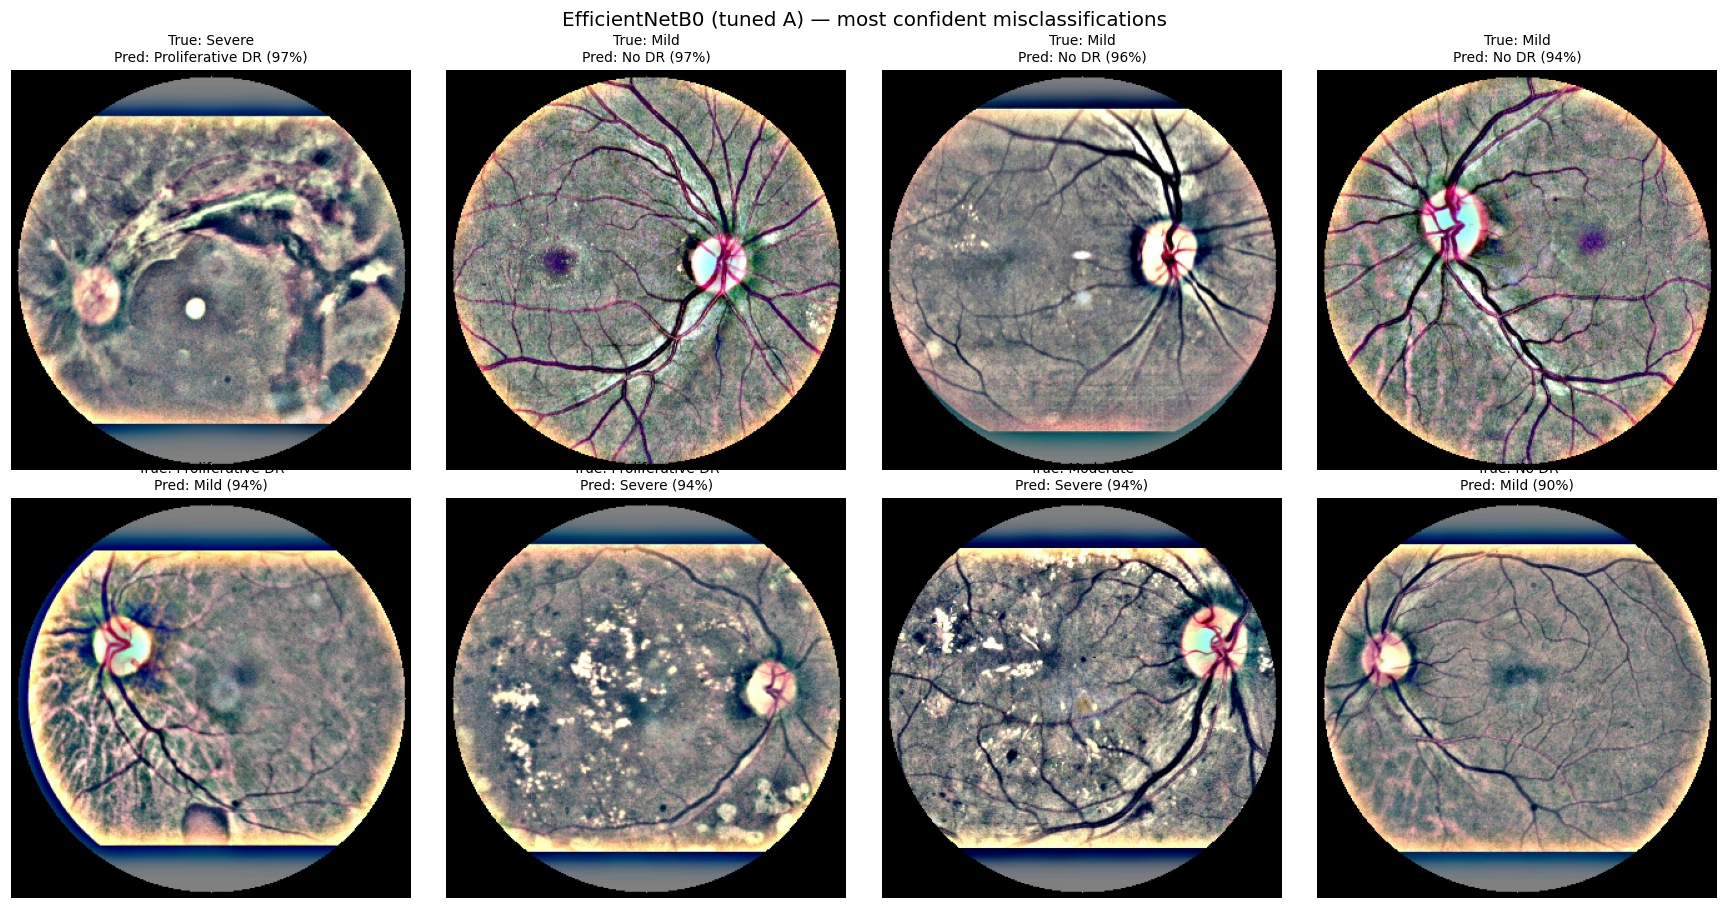

In [ ]:
# --- Look at the images the model got wrong ---------------------------------
import cv2

def load_rgb(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

wrong_idx = np.where(e["y_pred"] != e["y_true"])[0]
confidence = e["probs"].max(axis=1)
# Most confidently wrong predictions are the most diagnostic of model failure
worst = wrong_idx[np.argsort(-confidence[wrong_idx])][:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 8.4))
for ax, idx in zip(axes.flat, worst):
    ax.imshow(load_rgb(test_df["cached_path"].iloc[idx]))
    ax.set_title(f"True: {CLASS_NAMES[e['y_true'][idx]]}\n"
                 f"Pred: {CLASS_NAMES[e['y_pred'][idx]]} ({confidence[idx]*100:.0f}%)",
                 fontsize=9)
    ax.axis("off")
plt.suptitle(f"{BEST} — most confident misclassifications", fontsize=13)
plt.tight_layout()
save_fig("11_misclassified_examples")
plt.show()

---
## 8. Grad-CAM interpretability

A clinician will not act on a prediction they cannot inspect. Gradient-weighted Class
Activation Mapping shows which image regions drove the decision: it weights the final
convolutional feature maps by the gradient of the predicted class score with respect to
those maps, then overlays the result as a heatmap.

This is worth doing carefully because it is genuine evidence, not decoration. If the
heatmaps concentrate on haemorrhages and exudates, the model has learned clinically
relevant features. If they concentrate on the image border or the optic disc in every
case, the model is exploiting an artefact — and saying so honestly is far more valuable
than claiming success.

In [6]:
def grad_cam(backbone, head, image_batch, class_index=None):
    '''Compute a Grad-CAM heatmap.

    Works by running backbone and head explicitly rather than rebuilding a
    sub-model, which avoids graph-surgery issues with nested Keras models.

    Args:
        image_batch: preprocessed tensor of shape (1, H, W, 3)
        class_index: class to explain; defaults to the predicted class
    Returns:
        heatmap (h, w) normalised to [0, 1], and the predicted class index
    '''
    image_batch = tf.cast(image_batch, tf.float32)

    with tf.GradientTape() as tape:
        features = backbone(image_batch, training=False)
        tape.watch(features)
        preds = head(features, training=False)
        idx = tf.argmax(preds[0]) if class_index is None else class_index
        score = preds[:, idx]

    grads = tape.gradient(score, features)                 # (1, h, w, C)
    if grads is None:
        raise RuntimeError("No gradient reached the feature map. Check that the "
                           "backbone and head are the ones used for training.")

    weights = tf.reduce_mean(grads, axis=(1, 2))           # (1, C) channel importance
    cam = tf.reduce_sum(features * weights[:, None, None, :], axis=-1)[0]
    cam = tf.nn.relu(cam)                                  # only positive contributions

    # Normalise by the actual peak, not peak + epsilon. Adding an epsilon looks
    # harmless but silently flattens the map to zero whenever the peak is smaller
    # than the epsilon, which produces a blank heatmap with no error message.
    peak = tf.reduce_max(cam)
    if float(peak) <= 0.0:
        print("  Grad-CAM warning: no positive evidence for this class - blank map. "
              "Expected with an untrained model; investigate if it happens after training.")
        return np.zeros(cam.shape, dtype=np.float32), int(idx)

    return (cam / peak).numpy(), int(idx)


def overlay_heatmap(rgb_image, heatmap, alpha=0.4):
    '''Resize the heatmap to the image and blend it with a jet colourmap.'''
    hm = cv2.resize(heatmap, (rgb_image.shape[1], rgb_image.shape[0]))
    hm = np.uint8(255 * hm)
    hm = cv2.applyColorMap(hm, cv2.COLORMAP_JET)
    hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
    return np.uint8(rgb_image * (1 - alpha) + hm * alpha)

In [7]:
# --- Reload the final model from Drive (no retraining needed) -----------------
import cv2

FINAL_KEY  = "EfficientNetB0 (tuned A)"
FINAL_FILE = "EfficientNetB0_tuneA"

m = keras.models.load_model(MODEL_DIR / f"{FINAL_FILE}_final.keras")
head     = m.get_layer("head")
backbone = [l for l in m.layers if isinstance(l, keras.Model) and l.name != "head"][0]

best_res = {"model": m, "backbone": backbone, "head": head,
            "preprocess": keras.applications.efficientnet.preprocess_input}
prep = best_res["preprocess"]
BEST = FINAL_KEY

print("Loaded:", FINAL_KEY, "| backbone:", backbone.name)

Loaded: EfficientNetB0 (tuned A) | backbone: efficientnetb0


  saved -> 12_gradcam.png


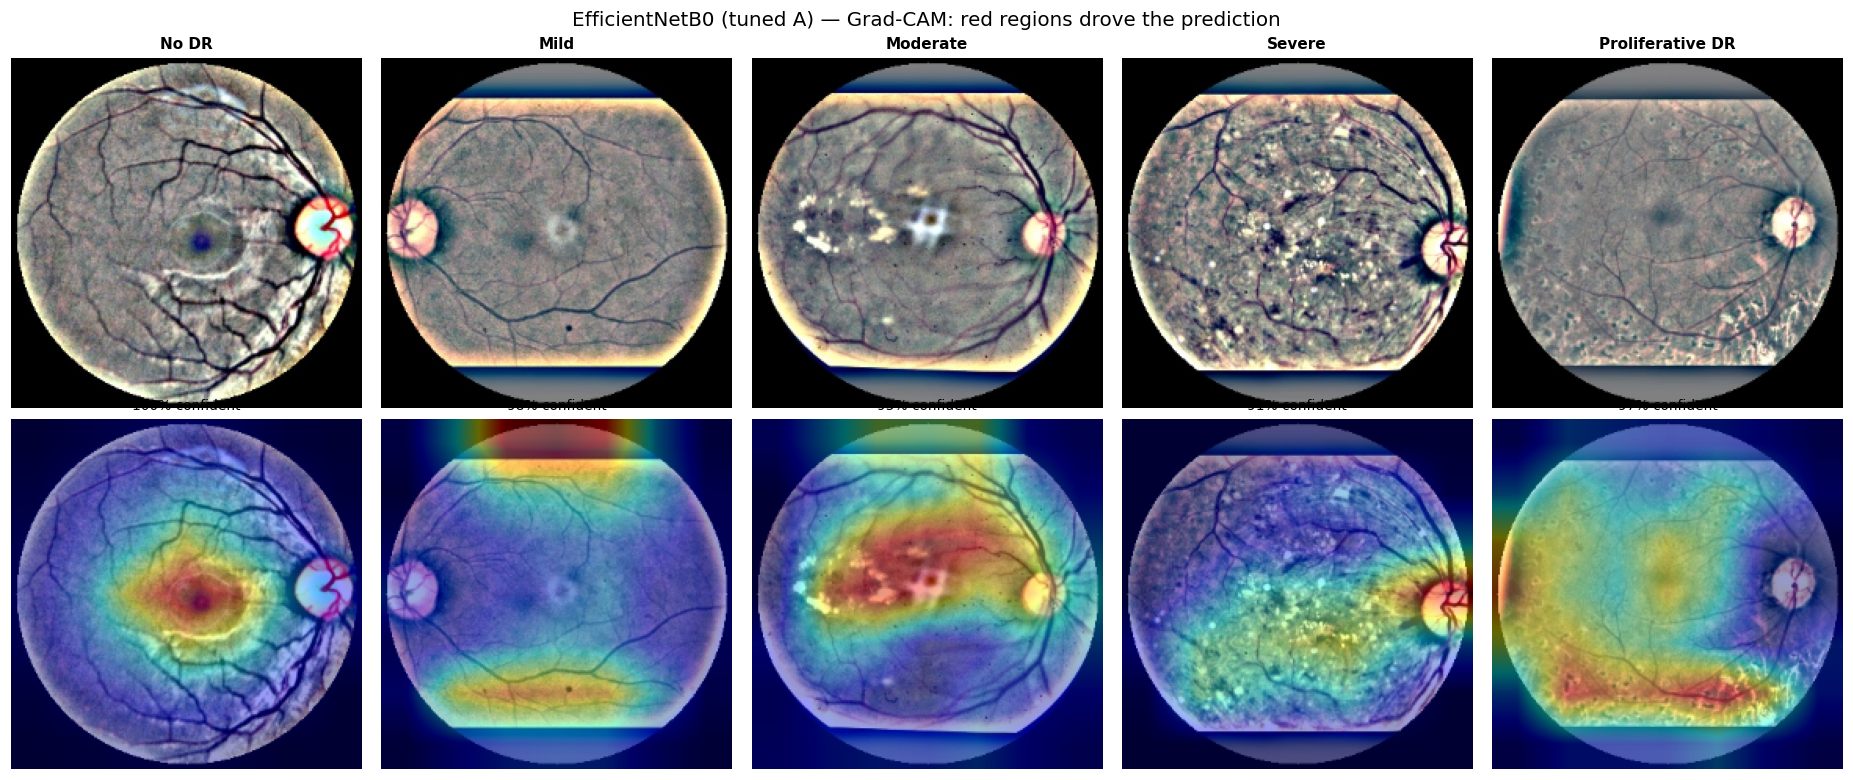

In [ ]:
# --- Grad-CAM on one correctly classified example per class -----------------
best_res = results[BEST]
prep = best_res["preprocess"]          # correct normalisation for the chosen model

correct = np.where(e["y_pred"] == e["y_true"])[0]
picks = []
for c in range(NUM_CLASSES):
    candidates = [i for i in correct if e["y_true"][i] == c]
    if candidates:
        picks.append(max(candidates, key=lambda i: confidence[i]))

fig, axes = plt.subplots(2, len(picks), figsize=(3.4 * len(picks), 7.2))
for col, idx in enumerate(picks):
    path = test_df["cached_path"].iloc[idx]
    raw = load_rgb(path)
    raw = cv2.resize(raw, (IMG_SIZE, IMG_SIZE))

    batch = prep(tf.cast(raw[None, ...], tf.float32))
    hm, pred_idx = grad_cam(best_res["backbone"], best_res["head"], batch)

    axes[0, col].imshow(raw); axes[0, col].axis("off")
    axes[0, col].set_title(CLASS_NAMES[e["y_true"][idx]], fontsize=10, fontweight="bold")
    axes[1, col].imshow(overlay_heatmap(raw, hm)); axes[1, col].axis("off")
    axes[1, col].set_title(f"{confidence[idx]*100:.0f}% confident", fontsize=9)

axes[0, 0].set_ylabel("Input"); axes[1, 0].set_ylabel("Grad-CAM")
plt.suptitle(f"{BEST} — Grad-CAM: red regions drove the prediction", fontsize=13)
plt.tight_layout()
save_fig("12_gradcam")
plt.show()

Sanity check - test accuracy: 0.7800 (expected 0.7800)
  saved -> 08c_final_model_curves_cm.png


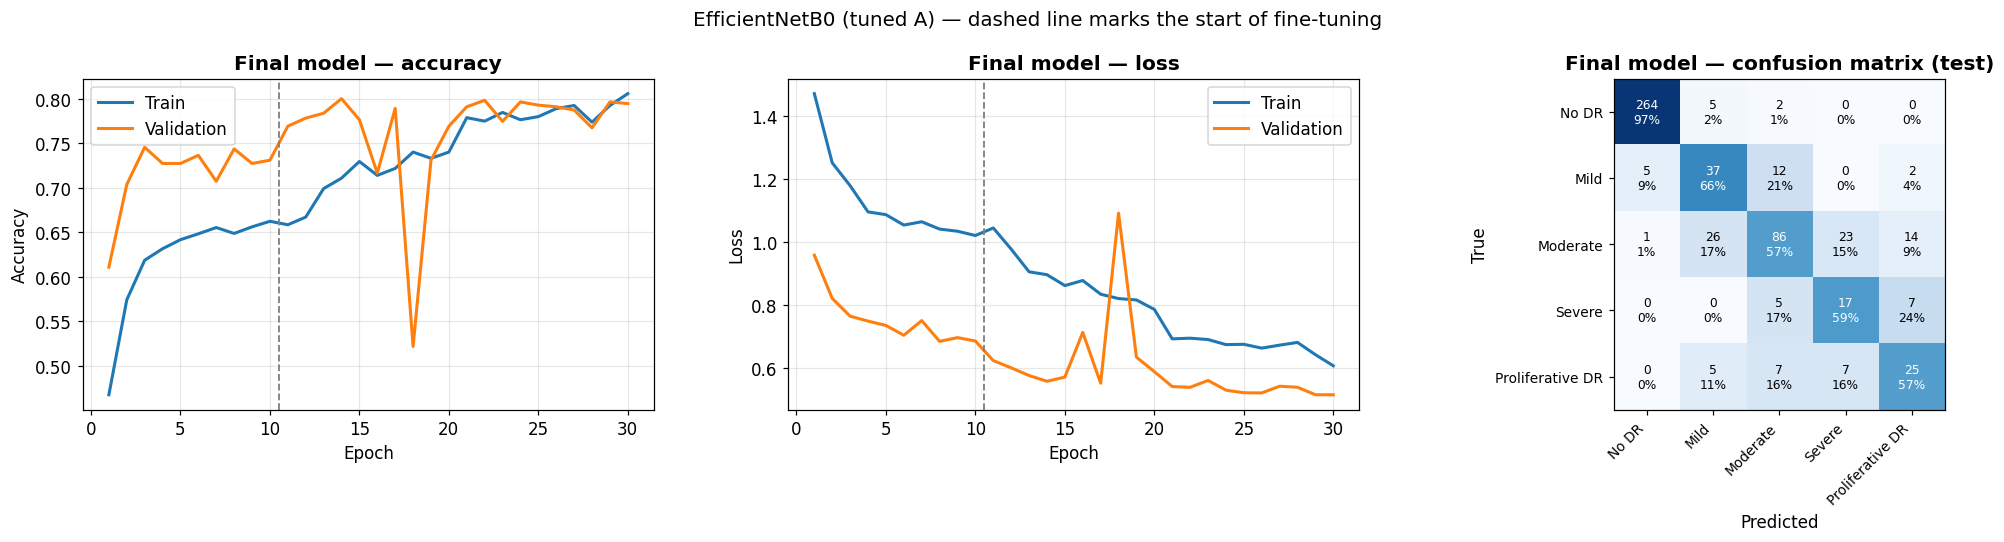

In [ ]:
# --- Final model: accuracy/loss curves + confusion matrix ---------------------
FINAL_KEY, FINAL_FILE = "EfficientNetB0 (tuned A)", "EfficientNetB0_tuneA"

with open(RESULT_DIR / f"{FINAL_FILE}_history.json") as f:
    h = json.load(f)
b, ep = h["stage_boundary"], range(1, len(h["loss"]) + 1)

y_true, y_pred = evaluations[FINAL_KEY]["y_true"], evaluations[FINAL_KEY]["y_pred"]
print(f"Sanity check - test accuracy: {accuracy_score(y_true, y_pred):.4f} (expected 0.7800)")

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, k in [(axes[0], "accuracy"), (axes[1], "loss")]:
    ax.plot(ep, h[k], lw=2, label="Train")
    ax.plot(ep, h[f"val_{k}"], lw=2, label="Validation")
    ax.axvline(b + 0.5, ls="--", c="grey", lw=1.2)
    ax.set_xlabel("Epoch"); ax.set_ylabel(k.capitalize())
    ax.set_title(f"Final model — {k}", fontweight="bold"); ax.legend()

cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
axes[2].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1); axes[2].grid(False)
axes[2].set_xticks(range(NUM_CLASSES)); axes[2].set_yticks(range(NUM_CLASSES))
axes[2].set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=9)
axes[2].set_yticklabels(CLASS_NAMES, fontsize=9)
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
axes[2].set_title("Final model — confusion matrix (test)", fontweight="bold")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        axes[2].text(j, i, f"{cm[i, j]}\n{cm_norm[i, j]*100:.0f}%", ha="center", va="center",
                     fontsize=8, color="white" if cm_norm[i, j] > 0.5 else "black")

plt.suptitle(f"{FINAL_KEY} — dashed line marks the start of fine-tuning", fontsize=13)
plt.tight_layout(); save_fig("08c_final_model_curves_cm"); plt.show()

---
## 9. Deployment prototype

A Gradio interface gives a working demonstration: upload a fundus image, get a predicted
stage with per-class confidences and a Grad-CAM explanation.

**For a demonstration video:**
1. Show the notebook running and the training curves.
2. Open the Gradio link, upload two or three test images of different grades.
3. Point at the Grad-CAM heatmap and explain what the model is attending to.
4. State one honest limitation.

In [8]:
# --- Get RAW test-set images for the demo (images the model never trained on) ---
import os, zipfile, glob
from google.colab import files

# 1) Kaggle token - this is a new session, so it must be uploaded again
if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Upload kaggle.json:")
    up = files.upload()
    os.makedirs("/root/.kaggle", exist_ok=True)
    os.replace(list(up)[0], "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)

# 2) one raw image per class, taken from our own test split
demo_dir = "/content/demo_raw"
os.makedirs(demo_dir, exist_ok=True)
for cls in range(5):
    row = test_df[test_df["diagnosis"] == cls].iloc[0]
    remote = f'{row["split_folder"]}/{row["id_code"]}.png'
    !kaggle datasets download -d mariaherrerot/aptos2019 -f "{remote}" -p {demo_dir}
    for z in glob.glob(f"{demo_dir}/*.zip"):
        zipfile.ZipFile(z).extractall(demo_dir); os.remove(z)
    src = os.path.join(demo_dir, f'{row["id_code"]}.png')
    if os.path.exists(src):
        new = f'class{cls}_{CLASS_NAMES[cls].replace(" ", "_")}_{row["id_code"]}.png'
        os.rename(src, os.path.join(demo_dir, new))

print(sorted(os.listdir(demo_dir)))

# 3) zip them and download to the computer
!cd /content && zip -qj demo_raw.zip demo_raw/*.png
files.download("/content/demo_raw.zip")

Upload kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 1.82M/1.82M [00:01<00:00, 1.57MB/s]

Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 1.64M/1.64M [00:01<00:00, 1.54MB/s]

Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 845k/845k [00:01<00:00, 675kB/s]

Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 2.25M/2.25M [00:01<00:00, 2.00MB/s]

Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 5.34M/5.34M [00:01<00:00, 4.09MB/s]

['class0_No_DR_bb85097857fa.png', 'class1_Mild_a47432cd41e7.png', 'class2_Moderate_4ef0b485a7da.png', 'class3_Severe_dd3dad6ca78f.png', 'class4_Proliferative_DR_9cc6b1f9bcbd.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
!pip install -q gradio

In [10]:
# --- Inference-time preprocessing (same pipeline as Notebook 1) ---------------
# The model was trained on CLAHE + Ben Graham processed images, so any raw image
# uploaded to the demo must go through exactly the same steps first. Without this,
# the demo only works on images that were already preprocessed.

def crop_to_content(img, tol=7):
    '''Crop to the tightest bounding box of non-black pixels.'''
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol
    if not mask.any():
        return img
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    return img[rows[0]:rows[-1] + 1, cols[0]:cols[-1] + 1]


def pad_to_square(img):
    '''Zero-pad the shorter side so resizing keeps the retina's aspect ratio.'''
    h, w = img.shape[:2]
    size = max(h, w)
    top, left = (size - h) // 2, (size - w) // 2
    canvas = np.zeros((size, size, 3), dtype=img.dtype)
    canvas[top:top + h, left:left + w] = img
    return canvas


def circular_mask(img, shrink=0.97):
    '''Blank out everything outside the circular field of view.'''
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask, (w // 2, h // 2), int(min(h, w) // 2 * shrink), 1, thickness=-1)
    return img * mask[..., None]


def apply_clahe(img, clip=2.0, grid=8):
    '''Adaptive contrast enhancement on the LAB luminance channel only.'''
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=clip, tileGridSize=(grid, grid)).apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)


def ben_graham(img, sigma=10):
    '''Subtract the local colour average to expose low-contrast lesions.'''
    blurred = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma)
    return cv2.addWeighted(img, 4, blurred, -4, 128)


def preprocess_array(img, size=320):
    '''Full Notebook 1 pipeline for an in-memory RGB array (e.g. a Gradio upload).'''
    img = crop_to_content(img[..., :3])          # drop alpha channel if present
    img = pad_to_square(img)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    img = apply_clahe(img)
    img = ben_graham(img, sigma=10)
    return circular_mask(img)

In [11]:
import gradio as gr

def predict_fundus(image):
    '''Gradio callback: raw uploaded image in, (label dict, heatmap overlay) out.'''
    if image is None:
        return {}, None

    img = cv2.resize(preprocess_array(image), (IMG_SIZE, IMG_SIZE))
    batch = prep(tf.cast(img[None, ...], tf.float32))

    probs = best_res["model"].predict(batch, verbose=0)[0]
    hm, _ = grad_cam(best_res["backbone"], best_res["head"], batch)

    labels = {CLASS_NAMES[i]: float(probs[i]) for i in range(NUM_CLASSES)}
    return labels, overlay_heatmap(img, hm)


demo = gr.Interface(
    fn=predict_fundus,
    inputs=gr.Image(type="numpy", label="Upload a retinal fundus image"),
    outputs=[gr.Label(num_top_classes=5, label="Predicted DR stage"),
             gr.Image(label="Grad-CAM — what the model looked at")],
    title="Diabetic Retinopathy Stage Detection",
    description=(f"{BEST} with ImageNet transfer learning, trained on APTOS 2019. "
                 "Research prototype for coursework assessment — not a medical device "
                 "and not for clinical use."),
)

demo.launch(share=True, debug=False)   # public URL valid for ~72 hours; non-blocking

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c9cd130d80063133fe.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## 10. Saving results

In [ ]:
# --- Persist all results and metrics to Drive ------------------------------
summary = {
    "config": config,
    "final_model": BEST,
    "metrics": {a: evaluations[a]["metrics"] for a in evaluations},
    "class_weights": class_weights,
    "split_sizes": {"train": len(train_df), "val": len(val_df), "test": len(test_df)},
}
with open(RESULT_DIR / "final_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=float)

print(json.dumps(summary["metrics"], indent=2, default=float))
print(f"\nAll results written to {RESULT_DIR}")
print(f"All figures written to {FIG_DIR}")

{
  "EfficientNetB0": {
    "accuracy": 0.7618181818181818,
    "macro_f1": 0.5963902950465492,
    "weighted_f1": 0.7653177700002891,
    "qwk": 0.8313091057110672,
    "params": 4055976,
    "train_minutes": 28.4,
    "macro_auc": 0.9120997405644182
  },
  "ResNet50": {
    "accuracy": 0.7418181818181818,
    "macro_f1": 0.5681472693536331,
    "weighted_f1": 0.7389932072017317,
    "qwk": 0.8411446704606995,
    "params": 23597957,
    "train_minutes": 25.5,
    "macro_auc": 0.9097825965123576
  },
  "MobileNetV2": {
    "accuracy": 0.7018181818181818,
    "macro_f1": 0.5292296252253845,
    "weighted_f1": 0.7000553943690251,
    "qwk": 0.8074407473145344,
    "params": 2264389,
    "train_minutes": 35.3,
    "macro_auc": 0.9097983898297848
  },
  "EfficientNetB0 (tuned A)": {
    "accuracy": 0.78,
    "macro_f1": 0.6393898135063726,
    "weighted_f1": 0.7854036842761027,
    "qwk": 0.8699689520608426,
    "params": 4055976,
    "train_minutes": 35.4,
    "macro_auc": 0.931220894950

---
## 11. Results summary

### Figures produced across both notebooks

| File | Content |
|---|---|
| `01_class_distribution` | Dataset class distribution |
| `02_sample_images_by_class` | Example images per severity grade |
| `03_image_property_audit` | Raw image property analysis |
| `04_preprocessing_variants` | Preprocessing pipeline stages |
| `05_contrast_before_after` | Contrast improvement evidence |
| `06_split_stratification` | Train/val/test split verification |
| `07_augmentation_samples` | Augmentation examples |
| `08_training_curves` | Training and validation curves |
| `08b_tuning_curves` | Validation loss of the tuning runs |
| `08c_final_model_curves_cm` | Final model accuracy/loss curves and confusion matrix |
| `09_confusion_matrices` | Confusion matrices per architecture |
| `10_per_class_metrics` | Per-class precision/recall/F1 |
| `11_misclassified_examples` | Error analysis examples |
| `12_gradcam` | Grad-CAM interpretability |

### Limitations

- **Single-source data.** All images come from one hospital network in India. Performance
  on other populations, cameras and lighting conditions is unverified.
- **Small rare classes.** With roughly 29 Severe images in the test split, that class's
  recall has a wide confidence interval. One image changes it by about 3 percentage points.
- **Label noise.** Human graders disagree on DR staging, particularly between adjacent
  grades, so some apparent model errors may be label errors.
- **No patient-level separation.** If the dataset contains both eyes of one patient, they
  could fall on opposite sides of the split, slightly inflating results.
- **Not a medical device.** No regulatory validation, no prospective clinical evaluation.